In [7]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [8]:
api_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper)

In [9]:
wiki.run("What is Langchain?")

'Page: Model Context Protocol\nSummary: The Model Context Protocol (MCP) is an open standard and open-source framework introduced by Anthropic in November 2024 to standardize the way artificial intellig'

In [ ]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter


import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")



loader = WebBaseLoader("https://docs.langchain.com/langsmith/home")
docs = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
documents = text_splitter.split_documents(docs)
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vectordb = FAISS.from_documents(documents, embeddings)
retriever = vectordb.as_retriever()
retriever


USER_AGENT environment variable not set, consider setting it to identify your requests.


VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000013EF5A88ED0>, search_kwargs={})

In [11]:
from langchain_core.tools.retriever import create_retriever_tool

retrival_tool = create_retriever_tool(retriever, "langsmith_search", "Search for the information about langsmith. For any question about langsmith you must use this tool.")

In [12]:
retrival_tool.name

'langsmith_search'

In [13]:
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun

api_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=200)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
arxiv.name

'arxiv'

In [14]:
tools = [wiki, arxiv, retrival_tool]
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\atalb\\Documents\\Coding\\MLandAI\\Langchain\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=200)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=200)),
 StructuredTool(name='langsmith_search', description='Search for the information about langsmith. For any question about langsmith you must use this tool.', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x0000013EFDD97F60>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000

In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=os.getenv("GEMINI_API_KEY"))

In [16]:
# from langchainhub import pull
# prompt = pull("hwchase17/openai-functions-agent")
# prompt.messages


from langsmith import Client

client = Client()
# Pulling the updated "tools" version which is the current standard
prompt = client.pull_prompt("hwchase17/openai-tools-agent")

# To see the message structure as you did before:
print(prompt.messages)

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a helpful assistant'), additional_kwargs={}), MessagesPlaceholder(variable_name='chat_history', optional=True), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={}), MessagesPlaceholder(variable_name='agent_scratchpad')]


In [23]:
from langchain.agents import create_agent

agent = create_agent(llm, tools)

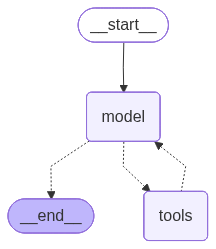

In [24]:
agent

In [ ]:
# 4. Run it
response = agent.invoke({"messages": [("user", "What is the paper 1605.08386 about?")]})
# print(response["messages"][-1].content)
response
# Langchain\agents\agents.ipynb
# Langchain\agents\agents.ipynb
# C:\Users\atalb\Documents\Coding\MLandAI\Langchain\Langchain\agents\agents.ipynb

{'messages': [HumanMessage(content='What is the paper 1605.08386 about?', additional_kwargs={}, response_metadata={}, id='a459df3a-7fe7-4331-9cd4-7a9410fa25f3'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'arxiv', 'arguments': '{"query": "1605.08386"}'}, '__gemini_function_call_thought_signatures__': {'ff1d61c1-a0b9-4ea9-9ac4-97c68e9a0de8': 'CooCAb4+9vuVBdLmCK3RVvLTCrcSZy3+x9ePzYQ/+xO8BN85sDwlMY6Rveta71a76y97HGoZdETK5DvOXuZ9u/CBl1yIcMHVhKcR8o4VCyazOz8ccJskGtEp9hgBXu3tgNEkWHKBELFQdobMbWUn7DL0Hbhlni6nIMP/QahqLjKh10Op1bxSQHVm5nFQeVtlR2UBm6SOG3ElLb7dw/9P1GpjSIzyOCbetR/3iTNI/ERp4qHHHiUqOy1O8iUyE0YEyuobfcra4V6gLED6zaBoph0n85241I/NaRi1OUgoX6+1E8OY8Oznqu13zdo7/nNxVm43PEWzaE0iOC8mIUd1J7alz9trS5ggJwIDSqw='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d2391-cf9e-7142-9429-90dbc1f91bbd-0', tool_calls=[{'name': 'arxiv', 'args': {'query': '1605.08386'}, 'id': 'ff1d61c

Failed to refresh cache entry hwchase17/openai-tools-agent: Failed to GET /commits/hwchase17/openai-tools-agent/latest in LangSmith API. Could not find a suitable TLS CA certificate bundle, invalid path: c:\Users\atalb\Documents\Coding\MLandAI\Langchain\.venv\Lib\site-packages\certifi\cacert.pem

Failed to refresh cache entry hwchase17/openai-tools-agent: Failed to GET /commits/hwchase17/openai-tools-agent/latest in LangSmith API. Could not find a suitable TLS CA certificate bundle, invalid path: c:\Users\atalb\Documents\Coding\MLandAI\Langchain\.venv\Lib\site-packages\certifi\cacert.pem

Failed to refresh cache entry hwchase17/openai-tools-agent: Failed to GET /commits/hwchase17/openai-tools-agent/latest in LangSmith API. Could not find a suitable TLS CA certificate bundle, invalid path: c:\Users\atalb\Documents\Coding\MLandAI\Langchain\.venv\Lib\site-packages\certifi\cacert.pem

Failed to refresh cache entry hwchase17/openai-tools-agent: Failed to GET /commits/hwchase17/openai-tools-